<a href="https://colab.research.google.com/github/ruthk11/drowsy-driver-detection/blob/main/driver_drowsiness_detection_ddd_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="font-family:Segoe UI,Arial,sans-serif;">Driver drowsiness detection (DDD)</h1>
<p style="font-family:Segoe UI,Arial,sans-serif;color:#444;font-size:14px;">
  PyTorch · Custom CNN vs ResNet-18 · Binary classification (Drowsy vs Non Drowsy)
</p>
<hr/>

<h2 style="font-family:Segoe UI,Arial,sans-serif;">1. Environment &amp; dependencies</h2>
<p style="color:#555;">GPU session, extra packages, imports.</p>

In [ ]:
!pip install -q scikit-learn tqdm matplotlib

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

<h2 style="font-family:Segoe UI,Arial,sans-serif;">2. Dataset location (Kaggle input)</h2>
<p style="color:#555;">Auto-detect folder that contains <code>Drowsy</code> and <code>Non Drowsy</code>.</p>

In [ ]:
def find_ddd_root(base: Path = Path("/kaggle/input")) -> Path:
    for p in base.rglob("*"):
        if not p.is_dir():
            continue
        try:
            sub = {c.name for c in p.iterdir() if c.is_dir()}
        except OSError:
            continue
        if "Drowsy" in sub and "Non Drowsy" in sub:
            return p
    raise FileNotFoundError("Add DDD dataset under /kaggle/input")

DATA_ROOT = find_ddd_root()
print("DATA_ROOT =", DATA_ROOT)

DATA_ROOT = /kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)


<h2 style="font-family:Segoe UI,Arial,sans-serif;">3. Data distribution (class balance)</h2>
<p style="color:#555;">Image counts per class — useful for reporting imbalance.</p>

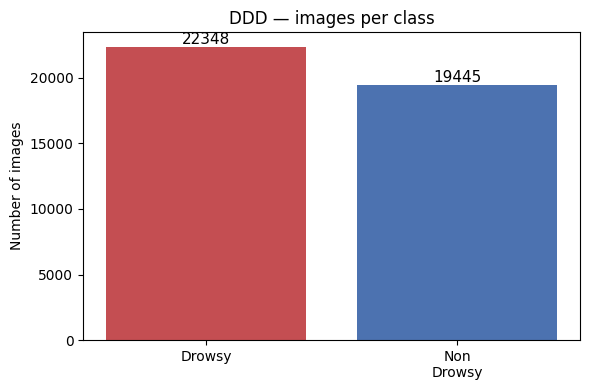

Total images: 41793
Ratio Drowsy : Non Drowsy = 1.149 : 1


In [ ]:
from collections import Counter

ext_ok = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}
labels, counts = [], []
for cls in ["Drowsy", "Non Drowsy"]:
    folder = Path(DATA_ROOT) / cls
    n = sum(1 for f in folder.iterdir() if f.is_file() and f.suffix.lower() in ext_ok)
    labels.append(cls.replace(" ", "\n"))
    counts.append(n)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts, color=["#c44e52", "#4c72b0"])
ax.set_ylabel("Number of images")
ax.set_title("DDD — images per class")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), str(c), ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

total = sum(counts)
print("Total images:", total)
print("Ratio Drowsy : Non Drowsy =", f"{counts[0]/counts[1]:.3f} : 1")

<h2 style="font-family:Segoe UI,Arial,sans-serif;">4. Qualitative check — sample images</h2>
<p style="color:#555;">One random example per class (RGB).</p>

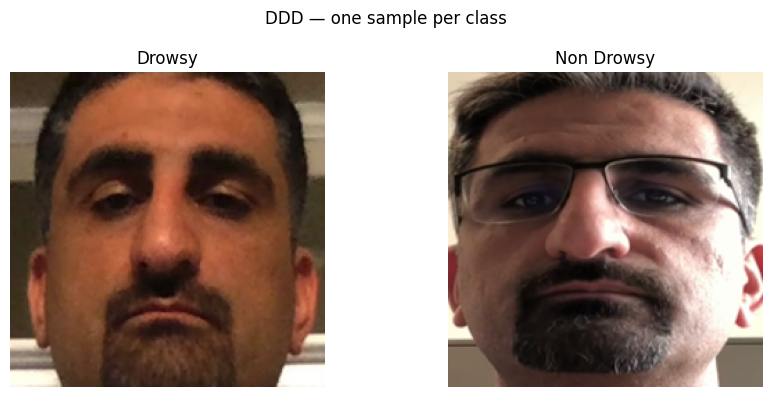

In [ ]:
def first_image(folder: Path) -> Path:
    for pat in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
        xs = sorted(folder.glob(pat))
        if xs:
            return xs[0]
    raise FileNotFoundError(folder)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, cls in zip(axes, ["Drowsy", "Non Drowsy"]):
    ip = first_image(Path(DATA_ROOT) / cls)
    ax.imshow(Image.open(ip).convert("RGB"))
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("DDD — one sample per class")
plt.tight_layout()
plt.show()

<h2 style="font-family:Segoe UI,Arial,sans-serif;">5. Compute device</h2>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128 | device: cuda
GPU: Tesla T4


<h2 style="font-family:Segoe UI,Arial,sans-serif;">6. Training scripts (<code>/kaggle/working</code>)</h2>
<p style="color:#555;">Use separate cells with <code>%%writefile</code> for <code>models.py</code>, <code>data_utils.py</code>, <code>metrics_utils.py</code>, <code>train.py</code> (one file per cell).</p>

In [ ]:
%%writefile /kaggle/working/models.py
"""Custom CNN vs ResNet for binary drowsiness classification."""

from __future__ import annotations

import torch
import torch.nn as nn
from torchvision import models


class CustomCNN(nn.Module):
    """Small CNN trained from scratch; input expects RGB 224x224 (resize in transforms)."""

    def __init__(self, num_classes: int = 2) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


def build_resnet(num_classes: int = 2, variant: str = "resnet18", pretrained: bool = True) -> nn.Module:
    variant = variant.lower()
    weights = None
    if pretrained:
        if variant == "resnet18":
            weights = models.ResNet18_Weights.IMAGENET1K_V1
            m = models.resnet18(weights=weights)
        elif variant == "resnet34":
            weights = models.ResNet34_Weights.IMAGENET1K_V1
            m = models.resnet34(weights=weights)
        else:
            raise ValueError(f"Unsupported ResNet variant: {variant}")
    else:
        if variant == "resnet18":
            m = models.resnet18(weights=None)
        elif variant == "resnet34":
            m = models.resnet34(weights=None)
        else:
            raise ValueError(f"Unsupported ResNet variant: {variant}")

    in_features = m.fc.in_features
    m.fc = nn.Linear(in_features, num_classes)
    return m


def build_model(name: str, num_classes: int = 2, resnet_variant: str = "resnet18", pretrained: bool = True) -> nn.Module:
    name = name.lower()
    if name == "cnn":
        return CustomCNN(num_classes=num_classes)
    if name == "resnet":
        return build_resnet(num_classes=num_classes, variant=resnet_variant, pretrained=pretrained)
    raise ValueError("name must be 'cnn' or 'resnet'")

Writing /kaggle/working/models.py


In [ ]:
%%writefile /kaggle/working/data_utils.py
"""Load Driver Drowsiness Dataset (DDD) style folder layout with ImageFolder."""

from __future__ import annotations

import random
from pathlib import Path
from typing import Tuple

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


def _train_val_split(dataset: datasets.ImageFolder, val_ratio: float, seed: int) -> Tuple[Subset, Subset]:
    n = len(dataset)
    indices = list(range(n))
    random.Random(seed).shuffle(indices)
    n_val = max(1, int(n * val_ratio))
    val_indices = indices[:n_val]
    train_indices = indices[n_val:]
    return Subset(dataset, train_indices), Subset(dataset, val_indices)


def get_transforms(img_size: int = 224):
    train_tf = transforms.Compose(
        [
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    eval_tf = transforms.Compose(
        [
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    return train_tf, eval_tf


def make_dataloaders(
    data_root: Path,
    batch_size: int = 32,
    val_ratio: float = 0.15,
    num_workers: int = 0,
    img_size: int = 224,
    seed: int = 42,
) -> Tuple[DataLoader, DataLoader, datasets.ImageFolder]:
    data_root = Path(data_root)
    if not data_root.is_dir():
        raise FileNotFoundError(f"data_root not found: {data_root}")

    train_tf, eval_tf = get_transforms(img_size)
    full = datasets.ImageFolder(str(data_root), transform=train_tf)
    train_subset, val_subset = _train_val_split(full, val_ratio=val_ratio, seed=seed)

    train_indices = train_subset.indices
    val_indices = val_subset.indices
    train_set = Subset(datasets.ImageFolder(str(data_root), transform=train_tf), train_indices)
    val_set = Subset(datasets.ImageFolder(str(data_root), transform=eval_tf), val_indices)

    g = torch.Generator()
    g.manual_seed(seed)
    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        generator=g,
    )
    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    ref = datasets.ImageFolder(str(data_root))
    return train_loader, val_loader, ref

Overwriting /kaggle/working/data_utils.py


In [ ]:
%%writefile /kaggle/working/metrics_utils.py
"""Classification metrics for binary (or small multi-class) problems."""

from __future__ import annotations

from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader
from tqdm import tqdm


@torch.no_grad()
def evaluate_loader(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> Tuple[float, Dict[str, float], np.ndarray, np.ndarray]:
    model.eval()
    all_preds: List[int] = []
    all_labels: List[int] = []
    loss_sum = 0.0
    n = 0
    criterion = nn.CrossEntropyLoss()

    for images, labels in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss_sum += loss.item() * labels.size(0)
        n += labels.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    avg_loss = loss_sum / max(n, 1)

    acc = float(accuracy_score(y_true, y_pred))
    precision = float(precision_score(y_true, y_pred, average="binary", zero_division=0))
    recall = float(recall_score(y_true, y_pred, average="binary", zero_division=0))
    f1 = float(f1_score(y_true, y_pred, average="binary", zero_division=0))

    metrics = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "loss": avg_loss,
    }
    return avg_loss, metrics, y_true, y_pred

Overwriting /kaggle/working/metrics_utils.py


In [ ]:
%%writefile /kaggle/working/train.py
"""
Train Custom CNN or ResNet on folder-based dataset (DDD / ImageFolder layout).
"""

from __future__ import annotations

import argparse
import json
from pathlib import Path

import torch
import torch.nn as nn
from tqdm import tqdm

from data_utils import make_dataloaders
from metrics_utils import evaluate_loader
from models import build_model


def train_one_epoch(
    model: nn.Module,
    loader,
    optimizer,
    criterion,
    device: torch.device,
    scaler: torch.amp.GradScaler | None,
    scheduler_batch: torch.optim.lr_scheduler.LRScheduler | None = None,
) -> float:
    model.train()
    total_loss = 0.0
    n = 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
        if scheduler_batch is not None:
            scheduler_batch.step()
        total_loss += loss.item() * labels.size(0)
        n += labels.size(0)
    return total_loss / max(n, 1)


def main() -> None:
    p = argparse.ArgumentParser()
    p.add_argument("--data_root", type=Path, required=True)
    p.add_argument("--model", choices=["cnn", "resnet"], default="cnn")
    p.add_argument("--resnet_variant", default="resnet18", choices=["resnet18", "resnet34"])
    p.add_argument("--no_pretrained", action="store_true")
    p.add_argument("--epochs", type=int, default=15)
    p.add_argument("--batch_size", type=int, default=32)
    p.add_argument("--lr", type=float, default=1e-3)
    p.add_argument("--weight_decay", type=float, default=1e-4)
    p.add_argument("--val_ratio", type=float, default=0.15)
    p.add_argument("--img_size", type=int, default=224)
    p.add_argument("--num_workers", type=int, default=0)
    p.add_argument("--seed", type=int, default=42)
    p.add_argument("--out_dir", type=Path, default=Path("runs/experiment"))
    p.add_argument("--amp", action="store_true")
    p.add_argument("--scheduler", choices=["cosine", "onecycle"], default="cosine")
    args = p.parse_args()

    torch.manual_seed(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, ref_dataset = make_dataloaders(
        data_root=args.data_root,
        batch_size=args.batch_size,
        val_ratio=args.val_ratio,
        num_workers=args.num_workers,
        img_size=args.img_size,
        seed=args.seed,
    )

    model = build_model(
        args.model,
        num_classes=len(ref_dataset.classes),
        resnet_variant=args.resnet_variant,
        pretrained=not args.no_pretrained,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    scheduler_epoch: torch.optim.lr_scheduler.LRScheduler | None = None
    scheduler_batch: torch.optim.lr_scheduler.LRScheduler | None = None
    if args.scheduler == "cosine":
        scheduler_epoch = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)
    else:
        scheduler_batch = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=args.lr,
            epochs=args.epochs,
            steps_per_epoch=len(train_loader),
            pct_start=0.3,
            div_factor=25.0,
            final_div_factor=1e4,
        )
    scaler = torch.amp.GradScaler("cuda") if args.amp and device.type == "cuda" else None

    args.out_dir.mkdir(parents=True, exist_ok=True)
    history = []
    best_f1 = -1.0
    best_path = args.out_dir / "best.pt"

    for epoch in range(1, args.epochs + 1):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler, scheduler_batch=scheduler_batch
        )
        val_loss, metrics, _, _ = evaluate_loader(model, val_loader, device)
        if scheduler_epoch is not None:
            scheduler_epoch.step()
        row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, **metrics}
        history.append(row)
        print(
            f"Epoch {epoch}/{args.epochs} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"acc={metrics['accuracy']:.4f} prec={metrics['precision']:.4f} rec={metrics['recall']:.4f} f1={metrics['f1']:.4f}"
        )
        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            torch.save(
                {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "classes": ref_dataset.classes,
                    "class_to_idx": ref_dataset.class_to_idx,
                    "args": vars(args),
                    "metrics": metrics,
                },
                best_path,
            )

    with open(args.out_dir / "history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)
    with open(args.out_dir / "classes.json", "w", encoding="utf-8") as f:
        json.dump({"classes": ref_dataset.classes, "class_to_idx": ref_dataset.class_to_idx}, f, indent=2)

    print(f"Done. Best F1={best_f1:.4f} | checkpoint: {best_path}")


if __name__ == "__main__":
    main()

Writing /kaggle/working/train.py


<h2 style="font-family:Segoe UI,Arial,sans-serif;">7. Model training</h2>
<p style="color:#555;">Custom CNN then ResNet-18 (ImageNet weights).</p>

In [ ]:
import os
import subprocess
import sys
from pathlib import Path

w = Path("/kaggle/working")
for name in ("models.py", "data_utils.py", "metrics_utils.py", "train.py"):
    if not (w / name).is_file():
        raise FileNotFoundError(
            f"Missing {name} in /kaggle/working/. Session restart clears working. "
            f"Run all %%writefile cells again (models → data_utils → metrics_utils → train), then this cell."
        )

dr = str(DATA_ROOT)
env = {**os.environ, "PYTHONPATH": str(w) + os.pathsep + os.environ.get("PYTHONPATH", "")}
subprocess.check_call(
    [
        sys.executable,
        str(w / "train.py"),
        "--data_root",
        dr,
        "--model",
        "cnn",
        "--epochs",
        "12",
        "--batch_size",
        "64",
        "--num_workers",
        "2",
        "--amp",
        "--out_dir",
        str(w / "runs" / "cnn1"),
    ],
    cwd=str(w),
    env=env,
)
print("CNN training finished.")

Train:   0%|          | 0/556 [00:00<?, ?it/s]          

Epoch 1/12 | train_loss=0.3030 val_loss=0.0573 acc=0.9842 prec=0.9788 rec=0.9872 f1=0.9830


Train:   0%|          | 0/556 [00:00<?, ?it/s]          

Epoch 2/12 | train_loss=0.1199 val_loss=0.0844 acc=0.9721 prec=0.9935 rec=0.9458 f1=0.9691


Train:   0%|          | 0/556 [00:00<?, ?it/s]          

...

Train:   0%|          | 0/556 [00:00<?, ?it/s]          

Epoch 10/12 | train_loss=0.0067 val_loss=0.0012 acc=0.9997 prec=0.9993 rec=1.0000 f1=0.9997


Train:   0%|          | 0/556 [00:00<?, ?it/s]          

Epoch 11/12 | train_loss=0.0044 val_loss=0.0012 acc=0.9997 prec=0.9993 rec=1.0000 f1=0.9997


Epoch 12/12 | train_loss=0.0036 val_loss=0.0008 acc=0.9997 prec=0.9993 rec=1.0000 f1=0.9997
Done. Best F1=0.9997 | checkpoint: /kaggle/working/runs/cnn1/best.pt
CNN training finished.


In [ ]:
import subprocess
import sys

dr = str(DATA_ROOT)
subprocess.check_call(
    [
        sys.executable,
        "/kaggle/working/train.py",
        "--data_root",
        dr,
        "--model",
        "resnet",
        "--resnet_variant",
        "resnet18",
        "--epochs",
        "8",
        "--batch_size",
        "64",
        "--num_workers",
        "2",
        "--amp",
        "--out_dir",
        "/kaggle/working/runs/resnet18",
    ]
)
print("ResNet training finished.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s] 
Train:   0%|          | 0/556 [00:00<?, ?it/s]          

Epoch 1/8 | train_loss=0.0473 val_loss=2.2945 acc=0.6862 prec=0.9979 rec=0.3217 f1=0.4866


Epoch 2/8 | train_loss=0.0233 val_loss=0.0006 acc=0.9998 prec=1.0000 rec=0.9997 f1=0.9998


Train:   0%|          | 0/556 [00:00<?, ?it/s]          

...

Epoch 5/8 | train_loss=0.0032 val_loss=0.0000 acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000


Train:   0%|          | 0/556 [00:00<?, ?it/s]          

Epoch 6/8 | train_loss=0.0009 val_loss=0.0000 acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000


Epoch 7/8 | train_loss=0.0002 val_loss=0.0000 acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000


Epoch 8/8 | train_loss=0.0001 val_loss=0.0000 acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000
Done. Best F1=1.0000 | checkpoint: /kaggle/working/runs/resnet18/best.pt
ResNet training finished.


<h2 style="font-family:Segoe UI,Arial,sans-serif;">8. Validation metrics summary</h2>
<p style="color:#555;">Last epoch + best F1 in each run.</p>

In [ ]:
def summarize_run(name, label):
    h = json.loads((Path("/kaggle/working/runs") / name / "history.json").read_text(encoding="utf-8"))
    last = h[-1]
    best_f1 = max(r["f1"] for r in h)
    print(f"\n{label}")
    print(f"  last: acc={last['accuracy']:.4f} prec={last['precision']:.4f} rec={last['recall']:.4f} f1={last['f1']:.4f}")
    print(f"  best F1 in run: {best_f1:.4f}")

summarize_run("cnn1", "Custom CNN")
summarize_run("resnet18", "ResNet-18")


Custom CNN
  last: acc=0.9997 prec=0.9993 rec=1.0000 f1=0.9997
  best F1 in run: 0.9997

ResNet-18
  last: acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000
  best F1 in run: 1.0000


<h2 style="font-family:Segoe UI,Arial,sans-serif;">9. Training curves (loss &amp; accuracy)</h2>

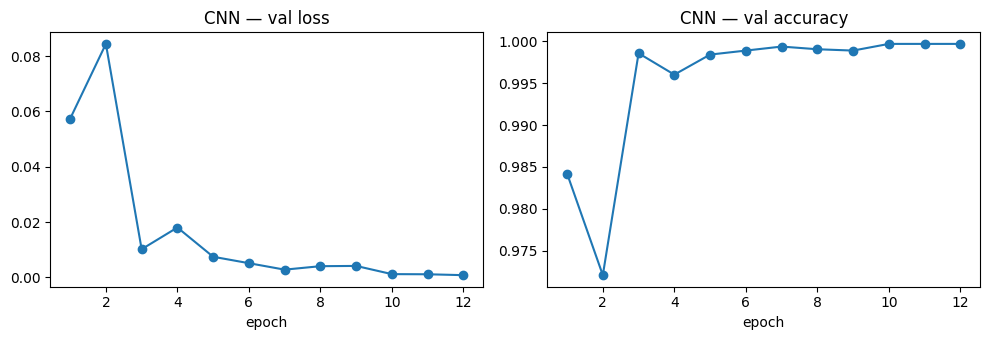

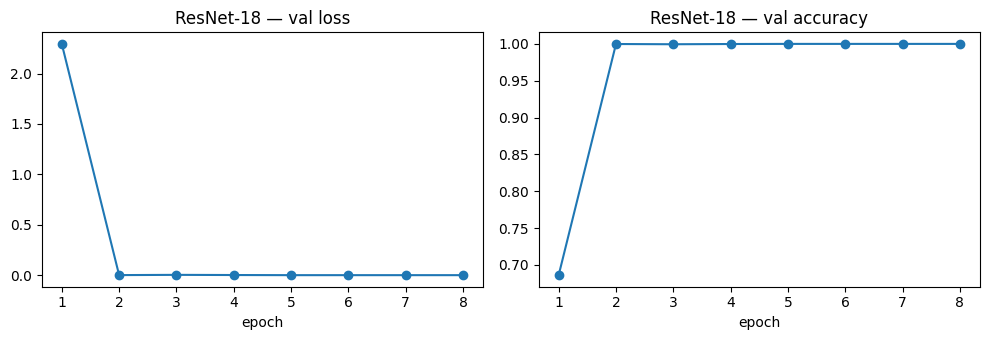

In [ ]:
def plot_curves(name, title):
    h = json.loads((Path("/kaggle/working/runs") / name / "history.json").read_text(encoding="utf-8"))
    e = [r["epoch"] for r in h]
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(e, [r["val_loss"] for r in h], marker="o")
    ax[0].set_title(f"{title} — val loss")
    ax[0].set_xlabel("epoch")
    ax[1].plot(e, [r["accuracy"] for r in h], marker="o")
    ax[1].set_title(f"{title} — val accuracy")
    ax[1].set_xlabel("epoch")
    plt.tight_layout()
    plt.show()

plot_curves("cnn1", "CNN")
plot_curves("resnet18", "ResNet-18")

<h2 style="font-family:Segoe UI,Arial,sans-serif;">10. Confusion matrices (validation set)</h2>
<p style="color:#555;">Reload best weights, same split as training (<code>seed=42</code>, <code>val_ratio=0.15</code>).</p>

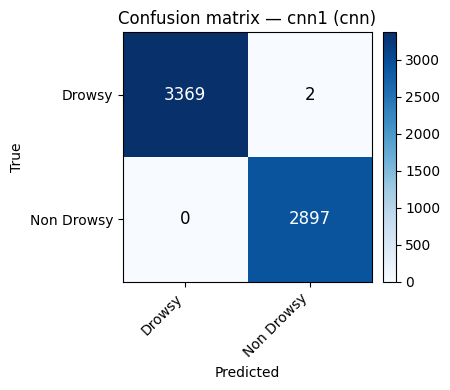

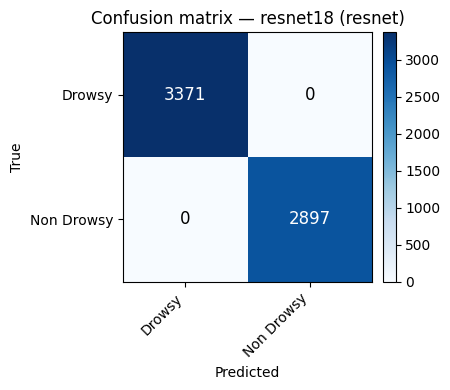

In [ ]:
from sklearn.metrics import confusion_matrix

# training-time modules must exist on path
sys.path.insert(0, "/kaggle/working")
from data_utils import make_dataloaders
from metrics_utils import evaluate_loader
from models import build_model


def plot_cm(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(cm.shape[1]))
    ax.set_yticks(np.arange(cm.shape[0]))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
    ax.set_title(title)
    thresh = cm.max() / 2 if cm.max() else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=12)
    plt.tight_layout()
    plt.show()


def cm_for_run(run_name, model_name, resnet_variant="resnet18"):
    ckpt_path = Path("/kaggle/working/runs") / run_name / "best.pt"
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    classes = ckpt["classes"]

    _, val_loader, ref = make_dataloaders(
        data_root=Path(DATA_ROOT),
        batch_size=64,
        val_ratio=0.15,
        num_workers=2,
        img_size=224,
        seed=42,
    )
    assert list(ref.classes) == list(classes)

    model = build_model(
        model_name,
        num_classes=len(classes),
        resnet_variant=resnet_variant,
        pretrained=model_name == "resnet",
    ).to(device)
    model.load_state_dict(ckpt["model_state"])

    _, _, y_true, y_pred = evaluate_loader(model, val_loader, device)
    plot_cm(y_true, y_pred, classes, f"Confusion matrix — {run_name} ({model_name})")


cm_for_run("cnn1", "cnn")
cm_for_run("resnet18", "resnet", resnet_variant="resnet18")

<h2 style="font-family:Segoe UI,Arial,sans-serif;">11. Preprocessing &amp; training settings (summary)</h2>
<ul style="font-family:Segoe UI,Arial,sans-serif;color:#555;">
  <li>Resize 227×227 (dataset) → 224×224 for models</li>
  <li>Train aug: flip, rotation, color jitter; val: resize + normalize only</li>
  <li>Normalize: ImageNet mean/std</li>
  <li>Optimizer: AdamW; loss: cross-entropy; AMP on GPU</li>
</ul>

<h2 style="font-family:Segoe UI,Arial,sans-serif;">12. Artifacts to download</h2>
<p style="color:#555;"><code>history.json</code>, <code>best.pt</code>, <code>classes.json</code> under each run folder.</p>

In [ ]:
for p in sorted(Path("/kaggle/working/runs").rglob("*")):
    if p.is_file() and p.suffix in {".json", ".pt"}:
        print(p)

/kaggle/working/runs/cnn1/best.pt
/kaggle/working/runs/cnn1/classes.json
/kaggle/working/runs/cnn1/history.json
/kaggle/working/runs/resnet18/best.pt
/kaggle/working/runs/resnet18/classes.json
/kaggle/working/runs/resnet18/history.json


<h2>Inference test (uploaded image)</h2>
<p>Kaggle server cannot use your laptop webcam. Upload a face image to <code>/kaggle/working/</code> (e.g. <code>test_face.png</code>) then set <code>IMG_PATH</code> below.</p>

In [ ]:
import sys
from pathlib import Path

import torch
from PIL import Image
from torchvision import transforms

sys.path.insert(0, "/kaggle/working")
from models import build_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CKPT_PATH = Path("/kaggle/working/runs/resnet18/best.pt")

eval_tfm = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
args = ckpt["args"]
if isinstance(args, dict):
    model_name = args.get("model", "resnet")
    resnet_variant = args.get("resnet_variant", "resnet18")
else:
    model_name = args.model
    resnet_variant = getattr(args, "resnet_variant", "resnet18")

classes = ckpt["classes"]
model = build_model(model_name, num_classes=len(classes), resnet_variant=resnet_variant, pretrained=False).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Loaded:", CKPT_PATH, "| classes:", classes)

Loaded: /kaggle/working/runs/resnet18/best.pt | classes: ['Drowsy', 'Non Drowsy']


In [ ]:
from pathlib import Path
from PIL import Image

# Use one real image from the dataset (no upload needed)
sample = next((Path(DATA_ROOT) / "Drowsy").glob("*.png"))
IMG_PATH = str(sample)
print("Using:", IMG_PATH)

img = Image.open(IMG_PATH).convert("RGB")
x = eval_tfm(img).unsqueeze(0).to(device)
with torch.no_grad():
    logits = model(x)
    p = torch.softmax(logits, dim=1)[0]
idx = int(p.argmax().item())
print("Prediction:", classes[idx], "| confidence:", float(p[idx].item()))
for i, c in enumerate(classes):
    print(f"  {c}: {float(p[i].item()):.4f}")

Using: /kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)/Drowsy/E0604.png
Prediction: Drowsy | confidence: 1.0
  Drowsy: 1.0000
  Non Drowsy: 0.0000


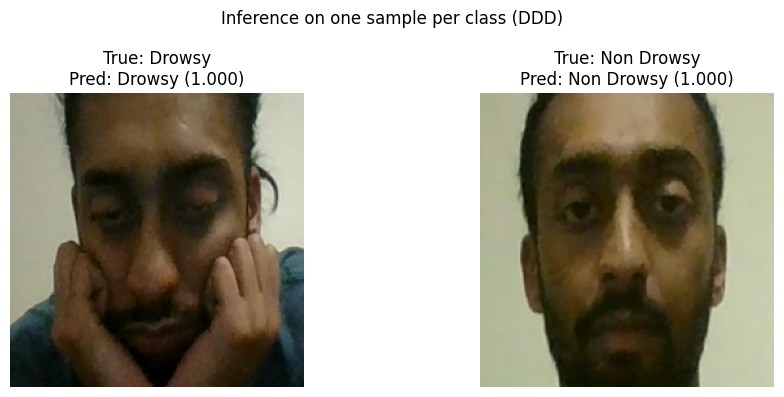

True: Drowsy | file: E0604.png | pred: Drowsy | conf: 1.0000
True: Non Drowsy | file: e0604.png | pred: Non Drowsy | conf: 1.0000


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, cls in zip(axes, ["Drowsy", "Non Drowsy"]):
    sample = next((Path(DATA_ROOT) / cls).glob("*.png"))
    img = Image.open(sample).convert("RGB")
    x = eval_tfm(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(x), dim=1)[0]
    idx = int(p.argmax().item())
    pred = classes[idx]
    conf = float(p[idx].item())

    ax.imshow(img)
    ax.set_title(f"True: {cls}\nPred: {pred} ({conf:.3f})")
    ax.axis("off")

plt.suptitle("Inference on one sample per class (DDD)", fontsize=12)
plt.tight_layout()
plt.show()

for cls in ["Drowsy", "Non Drowsy"]:
    sample = next((Path(DATA_ROOT) / cls).glob("*.png"))
    img = Image.open(sample).convert("RGB")
    x = eval_tfm(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(model(x), dim=1)[0]
    pred = classes[int(p.argmax().item())]
    print(f"True: {cls} | file: {sample.name} | pred: {pred} | conf: {float(p.max()):.4f}")